## Notebook Gráficas presentación Titanic:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df_titanic = pd.read_csv("./data/titanic.csv")

#### Tabla 1- El titanic fue un accidente con una tasa de mortalidad alta.  

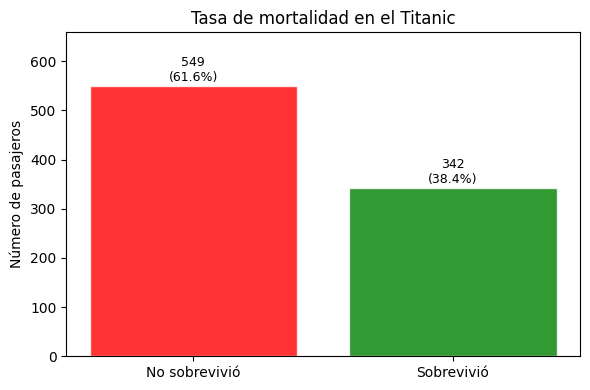

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

counts = df_titanic['survived'].value_counts().sort_index()
labels = ['No sobrevivió', 'Sobrevivió']
colors = ["red", "green"]

bars = ax.bar(labels, counts, color=colors, alpha=0.8, edgecolor="white")

total = counts.sum()
for bar, val in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{val}\n({val/total*100:.1f}%)',
        ha='center', va='bottom', fontsize = 9
    )

ax.set_title('Tasa de mortalidad en el Titanic', fontsize = 12)
ax.set_ylabel('Número de pasajeros')
ax.set_ylim(0, counts.max() * 1.2)
plt.tight_layout()
plt.savefig('slide1_mortalidad.png', dpi=150, bbox_inches='tight')
plt.show()

#### Tabla 2 - En esa ocasión los datos apoyan que se dio el "Las mujeres y los niños primero", pero...  

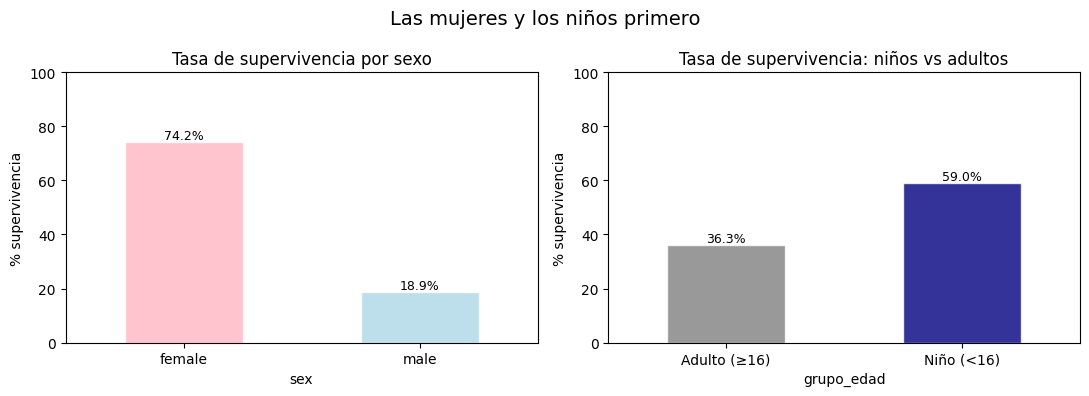

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

surv_sex = df_titanic.groupby('sex')['survived'].mean() * 100
surv_sex.plot(kind='bar', ax=axes[0], color=["lightpink", "lightblue"],
              alpha=0.8, edgecolor='white', rot=0)
axes[0].set_title('Tasa de supervivencia por sexo')
axes[0].set_ylabel('% supervivencia')
axes[0].set_ylim(0, 100)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=9)


df_titanic['grupo_edad'] = df_titanic['age'].apply(
    lambda x: 'Niño (<16)' if x < 16 else 'Adulto (≥16)'
)
surv_age = df_titanic.groupby('grupo_edad')['survived'].mean() * 100
surv_age.plot(kind='bar', ax=axes[1], color=["grey", "navy"],
              alpha=0.8, edgecolor='white', rot=0)
axes[1].set_title('Tasa de supervivencia: niños vs adultos')
axes[1].set_ylabel('% supervivencia')
axes[1].set_ylim(0, 100)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=9)

fig.suptitle('Las mujeres y los niños primero', fontsize=14)
plt.tight_layout()
plt.savefig('slide2_mujeres_ninos.png', dpi=150, bbox_inches='tight')
plt.show()

#### Tabla 3-  ... que la clase en la que se viajes tuvo una influencia significativa y podría explicar...

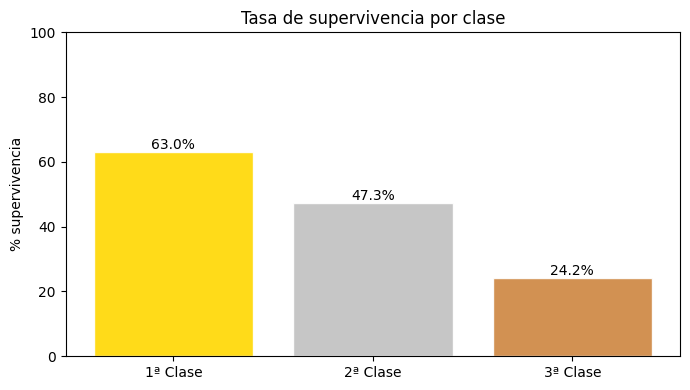

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))

surv_class = df_titanic.groupby('pclass')['survived'].mean() * 100
colores = ['gold', 'silver', 'peru']
bars = ax.bar(['1ª Clase', '2ª Clase', '3ª Clase'], surv_class,
              color=colores, alpha=0.9, edgecolor='white')

for bar, val in zip(bars, surv_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)

ax.set_title('Tasa de supervivencia por clase', fontsize=12)
ax.set_ylabel('% supervivencia')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('slide3_clase.png', dpi=150, bbox_inches='tight')
plt.show()

#### Tabla 4- ... las diferencias de tasas de supervivencia entre mujeres y niños.  

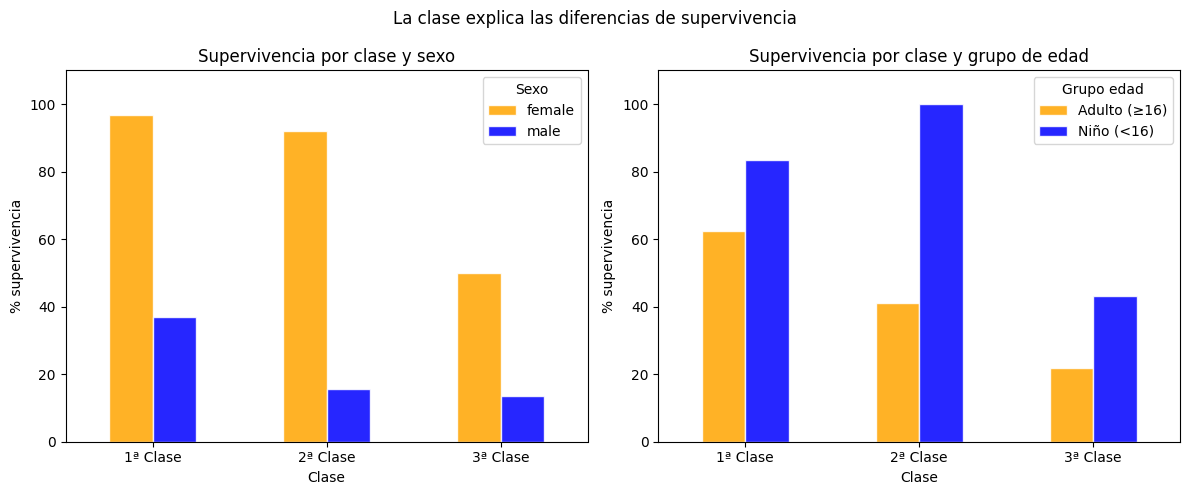

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

surv_cs = df_titanic.groupby(['pclass', 'sex'])['survived'].mean().unstack() * 100
surv_cs.plot(kind='bar', ax=axes[0], alpha=0.85, edgecolor='white', rot=0,
             color=["orange", "blue"])
axes[0].set_title('Supervivencia por clase y sexo')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('% supervivencia')
axes[0].set_ylim(0, 110)
axes[0].set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'])
axes[0].legend(title='Sexo')


surv_ca = df_titanic.groupby(['pclass', 'grupo_edad'])['survived'].mean().unstack() * 100
surv_ca.plot(kind='bar', ax=axes[1], alpha=0.85, edgecolor='white', rot=0,
              color=["orange", "blue"])
axes[1].set_title('Supervivencia por clase y grupo de edad')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('% supervivencia')
axes[1].set_ylim(0, 110)
axes[1].set_xticklabels(['1ª Clase', '2ª Clase', '3ª Clase'])
axes[1].legend(title='Grupo edad')

fig.suptitle('La clase explica las diferencias de supervivencia',
             fontsize=12)
plt.tight_layout()
plt.savefig('slide4_clase_sexo_edad.png', dpi=150, bbox_inches='tight')
plt.show()

#### TABLA 5- Además aunque el puerto de embarque parece influir, se podría asumir que lo fue el tipo de pasaje que embarcó en cada uno. 

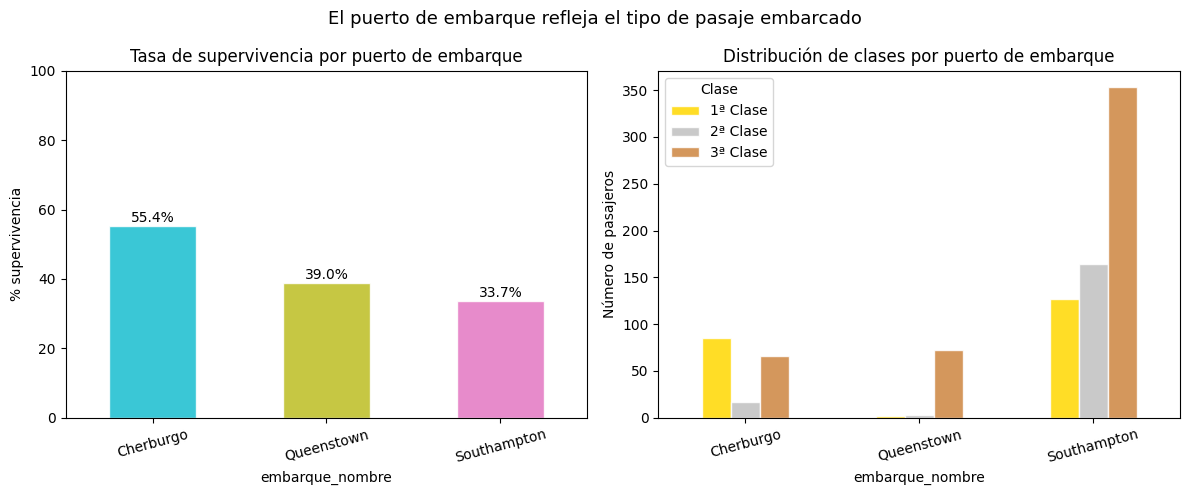

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

embarque_map = {'C': 'Cherburgo', 'Q': 'Queenstown', 'S': 'Southampton'}
df_titanic['embarque_nombre'] = df_titanic['embark_town'].map(
    {'Cherbourg': 'Cherburgo', 'Queenstown': 'Queenstown', 'Southampton': 'Southampton'}
)


surv_emb = df_titanic.groupby('embarque_nombre')['survived'].mean() * 100
surv_emb.plot(kind='bar', ax=axes[0], color=['#17becf', '#bcbd22', '#e377c2'],
              alpha=0.85, edgecolor='white', rot=15)
axes[0].set_title('Tasa de supervivencia por puerto de embarque')
axes[0].set_ylabel('% supervivencia')
axes[0].set_ylim(0, 100)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=10)


dist_class = df_titanic.groupby(['embarque_nombre', 'pclass']).size().unstack(fill_value=0)
dist_class.plot(kind='bar', ax=axes[1], alpha=0.85, edgecolor='white', rot=15,
                color=['gold', 'silver', 'peru'])
axes[1].set_title('Distribución de clases por puerto de embarque')
axes[1].set_ylabel('Número de pasajeros')
axes[1].legend(title='Clase', labels=['1ª Clase', '2ª Clase', '3ª Clase'])

fig.suptitle('El puerto de embarque refleja el tipo de pasaje embarcado',
             fontsize=13)
plt.tight_layout()
plt.savefig('slide5_puerto.png', dpi=150, bbox_inches='tight')
plt.show()